# Brain Tumor MRI DCGAN
Train a DCGAN to generate synthetic brain MRI images for data augmentation.
Replace the dataset path with your downloaded Kaggle dataset.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (11).zip to archive (11).zip


In [ ]:
import zipfile
import os

zip_path = "archive (11).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("brain_tumor_dataset")

In [ ]:
import os

for root, dirs, files in os.walk("brain_tumor_dataset"):
    print(f"Root: {root}")
    print(f"Folders: {dirs}")
    print(f"Files: {len(files)}")
    print("-"*50)

Root: brain_tumor_dataset
Folders: ['Training', 'Testing']
Files: 0
--------------------------------------------------
Root: brain_tumor_dataset/Training
Folders: ['notumor', 'pituitary', 'meningioma', 'glioma']
Files: 0
--------------------------------------------------
Root: brain_tumor_dataset/Training/notumor
Folders: []
Files: 1400
--------------------------------------------------
Root: brain_tumor_dataset/Training/pituitary
Folders: []
Files: 1400
--------------------------------------------------
Root: brain_tumor_dataset/Training/meningioma
Folders: []
Files: 1400
--------------------------------------------------
Root: brain_tumor_dataset/Training/glioma
Folders: []
Files: 1400
--------------------------------------------------
Root: brain_tumor_dataset/Testing
Folders: ['notumor', 'pituitary', 'meningioma', 'glioma']
Files: 0
--------------------------------------------------
Root: brain_tumor_dataset/Testing/notumor
Folders: []
Files: 400
-----------------------------------

In [ ]:
# Install if needed
# !pip install kaggle

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython import display


## Dataset

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 200

dataset_path = "brain_tumor_dataset/Training"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels=None,          # No labels needed for GAN
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

train_dataset = train_dataset.map(
    lambda x: (tf.cast(x, tf.float32) - 127.5) / 127.5
).prefetch(tf.data.AUTOTUNE)

Found 5600 files.


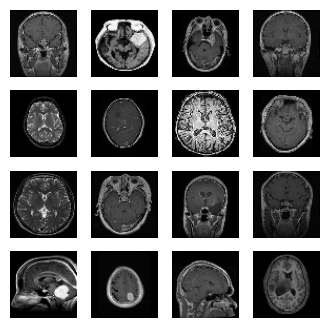

In [ ]:
for images in train_dataset.take(1):
    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow((images[i]+1)/2,cmap="gray")
        plt.axis("off")
    plt.show()


## Generator

In [ ]:
def make_generator():
    model=tf.keras.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(8*8*256,use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((8,8,256)),
        layers.Conv2DTranspose(128,5,2,padding="same",use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64,5,2,padding="same",use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(3,5,2,padding="same",activation="tanh")
    ])
    return model

generator=make_generator()
generator.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 3)      │         4,803 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,507 (10.43 MB)

 Trainable params: 2,700,355 (10.30 MB)

 Non-trainable params: 33,152 (129.50 KB)

## Discriminator

In [ ]:
def make_discriminator():
    model=tf.keras.Sequential([
        layers.Input(shape=(64,64,3)),
        layers.Conv2D(64,5,2,padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128,5,2,padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

discriminator=make_discriminator()
discriminator.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,561 (947.50 KB)

 Trainable params: 242,561 (947.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cross_entropy=tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real,fake):
    return cross_entropy(tf.ones_like(real),real)+cross_entropy(tf.zeros_like(fake),fake)

def g_loss(fake):
    return cross_entropy(tf.ones_like(fake),fake)

g_opt=tf.keras.optimizers.Adam(1e-4)
d_opt=tf.keras.optimizers.Adam(1e-4)


In [ ]:
seed=tf.random.normal([16,LATENT_DIM])

@tf.function
def train_step(images):
    noise=tf.random.normal([tf.shape(images)[0],LATENT_DIM])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake=generator(noise,training=True)
        real_out=discriminator(images,training=True)
        fake_out=discriminator(fake,training=True)

        gl=g_loss(fake_out)
        dl=d_loss(real_out,fake_out)

    g_grad=gt.gradient(gl,generator.trainable_variables)
    d_grad=dt.gradient(dl,discriminator.trainable_variables)

    g_opt.apply_gradients(zip(g_grad,generator.trainable_variables))
    d_opt.apply_gradients(zip(d_grad,discriminator.trainable_variables))

    return gl,dl


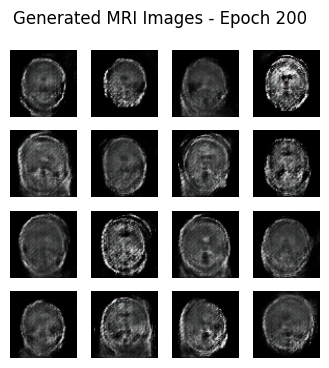

Epoch 200: G=1.4952, D=0.9719, Time=6.21s


In [ ]:
def generate_images(epoch):
    pred=generator(seed,training=False)
    plt.figure(figsize=(4,4))
    for i in range(pred.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow((pred[i]+1)/2)
        plt.axis("off")
    plt.suptitle(f"Generated MRI Images - Epoch {epoch}")
    plt.show()

def train(dataset,epochs):
    g_hist=[]
    d_hist=[]
    for epoch in range(1,epochs+1):
        start=time.time()
        for batch in dataset:
            gl,dl=train_step(batch)
        g_hist.append(float(gl))
        d_hist.append(float(dl))
        display.clear_output(wait=True)
        generate_images(epoch)
        print(f"Epoch {epoch}: G={gl:.4f}, D={dl:.4f}, Time={time.time()-start:.2f}s")
    return g_hist,d_hist

g_hist,d_hist=train(train_dataset,EPOCHS)


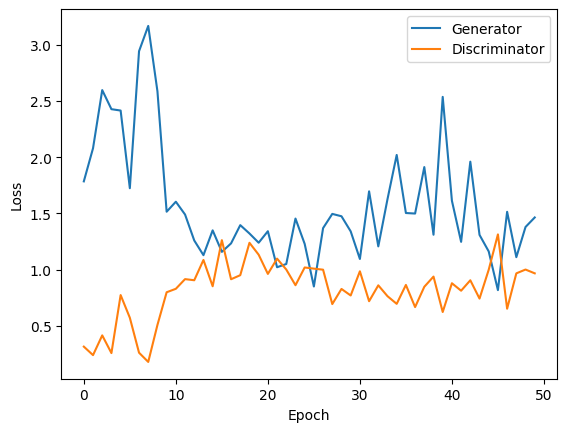

Models saved.


In [ ]:
plt.plot(g_hist,label="Generator")
plt.plot(d_hist,label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

generator.save("brain_mri_dcgan_generator.keras")
discriminator.save("brain_mri_dcgan_discriminator.keras")
print("Models saved.")
